# Member 6 - K-Nearest Neighbors (KNN) Regressor
## Medical Insurance Charges Prediction

### Objective
The objective of this model is to predict medical insurance charges using K-Nearest Neighbors Regression and identify a suitable KNN configuration through hyperparameter tuning.

### Model Suitability
KNN Regression is suitable for predicting the continuous target variable `charges`. It predicts a value based on the target values of similar observations in the training data.

This approach is useful for insurance data because individuals with similar characteristics such as age, BMI, smoking status, and other features may have similar insurance charges.

KNN can capture local and nonlinear patterns without assuming a specific mathematical relationship between the input features and the target. Since KNN is distance-based, feature scaling is important.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
candidate_roots = [
    Path("."),
    Path("..")
]

project_root = None

for root in candidate_roots:

    train_file = (
        root
        / "data"
        / "processed"
        / "insurance_train_processed.csv"
    )

    test_file = (
        root
        / "data"
        / "processed"
        / "insurance_test_processed.csv"
    )

    if train_file.exists() and test_file.exists():
        project_root = root
        break


if project_root is None:
    raise FileNotFoundError(
        "Processed train/test CSV files were not found. "
        "Check the data/processed folder."
    )


TRAIN_PATH = (
    project_root
    / "data"
    / "processed"
    / "insurance_train_processed.csv"
)

TEST_PATH = (
    project_root
    / "data"
    / "processed"
    / "insurance_test_processed.csv"
)

RESULT_PATH = (
    project_root
    / "results"
    / "model_results"
)

FIGURE_PATH = (
    project_root
    / "results"
    / "model_visualizations"
)


RESULT_PATH.mkdir(parents=True, exist_ok=True)
FIGURE_PATH.mkdir(parents=True, exist_ok=True)


print("Project root :", project_root)
print("Train file   :", TRAIN_PATH)
print("Test file    :", TEST_PATH)

Project root : ..
Train file   : ..\data\processed\insurance_train_processed.csv
Test file    : ..\data\processed\insurance_test_processed.csv


In [3]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)


print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape :", test_df.shape)


print("\nTraining Data:")
display(train_df.head())

print("\nTesting Data:")
display(test_df.head())


print(
    "\nTraining Missing Values:",
    train_df.isnull().sum().sum()
)

print(
    "Testing Missing Values:",
    test_df.isnull().sum().sum()
)


if "charges" not in train_df.columns:
    raise ValueError(
        "'charges' target column is missing from training data."
    )

if "charges" not in test_df.columns:
    raise ValueError(
        "'charges' target column is missing from testing data."
    )

Training Dataset Shape: (1069, 8)
Testing Dataset Shape : (268, 8)

Training Data:


,smoker_yes,age_bmi_interaction,age,bmi,region_southeast,children,sex_male,charges
0,0,-1.238193,-1.157680,-1.002462,0,-0.907908,1,2396.09590
1,0,-1.282622,-1.300619,-0.796635,0,0.766904,1,3279.86855
2,0,1.432285,0.914926,1.166632,0,0.766904,0,33471.97189
3,0,2.705024,1.701087,1.824110,1,-0.907908,1,13405.39030
4,0,0.082968,0.557580,-0.654140,0,0.766904,0,9715.84100



Testing Data:


,smoker_yes,age_bmi_interaction,age,bmi,region_southeast,children,sex_male,charges
0,0,-0.199877,0.700518,-1.334950,0,-0.907908,1,8688.85885
1,0,-0.894330,-0.728865,-0.820801,0,2.441716,0,5708.86700
2,0,1.248171,0.843457,0.976639,0,1.604310,0,11436.73815
3,1,-0.271365,-0.585927,0.644150,0,1.604310,1,38746.35510
4,0,-0.032718,-0.585927,1.310794,1,0.766904,1,4463.20510



Training Missing Values: 0
Testing Missing Values: 0


In [4]:
X_train = train_df.drop(
    columns=["charges"]
)

y_train = train_df["charges"]


X_test = test_df.drop(
    columns=["charges"]
)

y_test = test_df["charges"]


if list(X_train.columns) != list(X_test.columns):
    raise ValueError(
        "Training and testing feature columns do not match."
    )


print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)

print("X_test Shape :", X_test.shape)
print("y_test Shape :", y_test.shape)


print("\nFeatures Used:")

for feature in X_train.columns:
    print("-", feature)


print("\nTarget Statistics:")
display(y_train.describe())

X_train Shape: (1069, 7)
y_train Shape: (1069,)
X_test Shape : (268, 7)
y_test Shape : (268,)

Features Used:
- smoker_yes
- age_bmi_interaction
- age
- bmi
- region_southeast
- children
- sex_male

Target Statistics:


count     1069.000000
mean     13030.203369
std      11706.530971
min       1121.873900
25%       4747.052900
50%       9290.139500
75%      16450.894700
max      62592.873090
Name: charges, dtype: float64

In [5]:
def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )


    print(f"\n{model_name}")
    print("-" * 50)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")


    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

## Evaluation, Validation and Implementation

### Evaluation Metrics
The model is evaluated using:

- **MAE:** Measures the average absolute prediction error. Lower values indicate better performance.
- **RMSE:** Gives a larger penalty to large prediction errors. Lower values indicate better performance.
- **R²:** Measures how much variation in insurance charges is explained by the model. Higher values generally indicate better performance.

### Validation and Hyperparameter Tuning
Five-fold cross-validation is used during GridSearchCV to evaluate different KNN configurations.

The following hyperparameters are tuned:

- **n_neighbors:** Number of neighboring observations used to make a prediction.
- **weights:** Determines whether all neighbors contribute equally or closer neighbors receive greater influence.
- **p:** Determines the distance metric. `p=1` represents Manhattan distance and `p=2` represents Euclidean distance.

### Implementation
Scikit-learn `KNeighborsRegressor` is used to build the model and `GridSearchCV` is used for hyperparameter tuning. A baseline KNN model with `n_neighbors=5` is first evaluated and then compared with the tuned KNN model.

Because KNN uses distances between observations, appropriately scaled input features are important.

In [6]:
knn_baseline = KNeighborsRegressor(
    n_neighbors=5
)


knn_baseline.fit(
    X_train,
    y_train
)


baseline_predictions = (
    knn_baseline.predict(
        X_test
    )
)


baseline_result = evaluate_model(
    "KNN - Baseline (K=5)",
    y_test,
    baseline_predictions
)


KNN - Baseline (K=5)
--------------------------------------------------
MAE  : 3847.8057
RMSE : 6871.4059
R²   : 0.7430


In [7]:
param_grid = {

    "n_neighbors": [
        3,
        5,
        7,
        9,
        11,
        15,
        20
    ],

    "weights": [
        "uniform",
        "distance"
    ],

    "p": [
        1,
        2
    ]
}


knn_model = KNeighborsRegressor()


grid_search = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)


grid_search.fit(
    X_train,
    y_train
)


print(
    "Best Parameters:",
    grid_search.best_params_
)

print(
    "Best Cross-Validation RMSE:",
    -grid_search.best_score_
)

Best Parameters: {'n_neighbors': 5, 'p': 2, 'weights': 'distance'}
Best Cross-Validation RMSE: 6644.775115138293


In [8]:
cv_results = pd.DataFrame(
    grid_search.cv_results_
)


tuning_results = pd.DataFrame({

    "N_Neighbors":
        cv_results[
            "param_n_neighbors"
        ].astype(int),

    "Weights":
        cv_results[
            "param_weights"
        ],

    "P":
        cv_results[
            "param_p"
        ].astype(int),

    "Mean_Train_RMSE":
        -cv_results[
            "mean_train_score"
        ],

    "Mean_CV_RMSE":
        -cv_results[
            "mean_test_score"
        ],

    "CV_RMSE_STD":
        cv_results[
            "std_test_score"
        ]
})


tuning_results = (
    tuning_results
    .sort_values(
        "Mean_CV_RMSE"
    )
    .reset_index(
        drop=True
    )
)


print(
    "Top 10 KNN Configurations:"
)

display(
    tuning_results.head(10)
)

Top 10 KNN Configurations:


,N_Neighbors,Weights,P,Mean_Train_RMSE,Mean_CV_RMSE,CV_RMSE_STD
0,5,distance,2,-0.000000,6644.775115,604.105559
1,3,distance,2,-0.000000,6698.306624,588.436701
2,7,distance,2,-0.000000,6705.363209,713.537325
3,5,distance,1,-0.000000,6803.102280,600.244975
4,7,distance,1,-0.000000,6813.826293,657.213443
5,9,distance,2,-0.000000,6814.395155,589.492307
6,5,uniform,2,5318.358038,6831.636225,595.275882
7,9,distance,1,-0.000000,6843.356485,560.899599
8,3,uniform,2,4418.588252,6851.822326,609.417403
9,7,uniform,2,5852.487479,6920.334757,727.876296


In [9]:
best_knn_model = (
    grid_search.best_estimator_
)


best_params = (
    grid_search.best_params_
)


tuned_predictions = (
    best_knn_model.predict(
        X_test
    )
)


tuned_result = evaluate_model(
    "KNN - Tuned",
    y_test,
    tuned_predictions
)


print("\nBest Parameters:")

for parameter, value in best_params.items():
    print(
        f"{parameter}: {value}"
    )


KNN - Tuned
--------------------------------------------------
MAE  : 3816.3046
RMSE : 6923.0196
R²   : 0.7392

Best Parameters:
n_neighbors: 5
p: 2
weights: distance


In [10]:
knn_results = pd.DataFrame([
    baseline_result,
    tuned_result
])


knn_results = (
    knn_results
    .sort_values(
        by="RMSE"
    )
    .reset_index(
        drop=True
    )
)


print(
    "Baseline vs Tuned KNN:"
)

display(
    knn_results
)

Baseline vs Tuned KNN:


,Model,MAE,RMSE,R2
0,KNN - Baseline (K=5),3847.805677,6871.405892,0.743049
1,KNN - Tuned,3816.304563,6923.019593,0.739175


In [11]:
cv_scores = cross_val_score(

    best_knn_model,

    X_train,

    y_train,

    cv=5,

    scoring="neg_root_mean_squared_error",

    n_jobs=-1
)


cv_rmse_scores = -cv_scores


print(
    "Final KNN - 5-Fold CV RMSE Scores:"
)


for fold, score in enumerate(
    cv_rmse_scores,
    start=1
):

    print(
        f"Fold {fold}: {score:.4f}"
    )


print(
    f"\nMean CV RMSE: "
    f"{cv_rmse_scores.mean():.4f}"
)

print(
    f"CV RMSE Standard Deviation: "
    f"{cv_rmse_scores.std():.4f}"
)

Final KNN - 5-Fold CV RMSE Scores:
Fold 1: 7633.9213
Fold 2: 6772.5324
Fold 3: 6377.3838
Fold 4: 5774.1199
Fold 5: 6665.9182

Mean CV RMSE: 6644.7751
CV RMSE Standard Deviation: 604.1056


In [12]:
final_knn_result = evaluate_model(
    "KNN - Final Tuned Model",
    y_test,
    tuned_predictions
)


k_analysis = (
    tuning_results
    .groupby(
        "N_Neighbors",
        as_index=False
    )["Mean_CV_RMSE"]
    .min()
)


print(
    "\nBest CV RMSE for Each K Value:"
)

display(
    k_analysis
)


print(
    "\nBest Hyperparameters:",
    best_params
)


print(
    "Mean 5-Fold CV RMSE:",
    round(
        cv_rmse_scores.mean(),
        4
    )
)


KNN - Final Tuned Model
--------------------------------------------------
MAE  : 3816.3046
RMSE : 6923.0196
R²   : 0.7392

Best CV RMSE for Each K Value:


,N_Neighbors,Mean_CV_RMSE
0,3,6698.306624
1,5,6644.775115
2,7,6705.363209
3,9,6814.395155
4,11,6954.798527
5,15,7063.161645
6,20,7220.542362



Best Hyperparameters: {'n_neighbors': 5, 'p': 2, 'weights': 'distance'}
Mean 5-Fold CV RMSE: 6644.7751


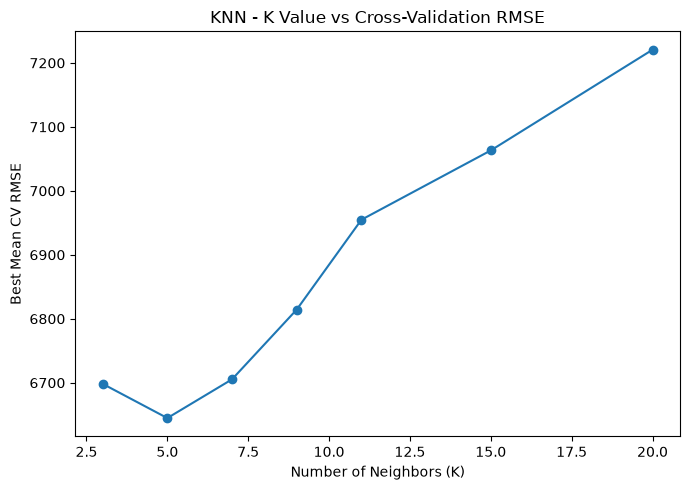

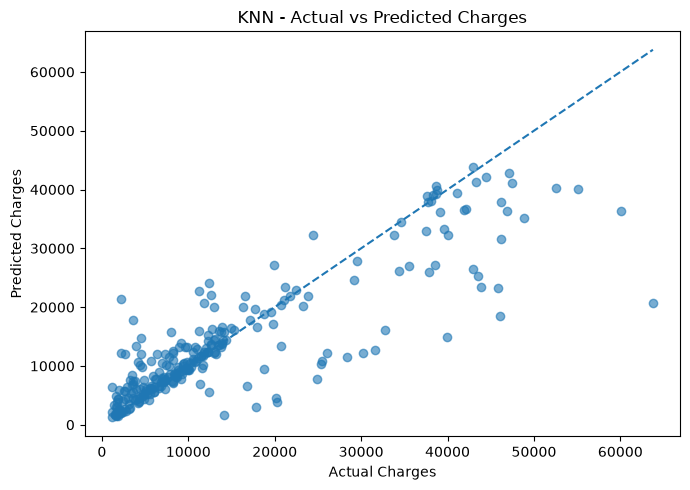

In [13]:
# K Value vs Cross-Validation RMSE
plt.figure(
    figsize=(7, 5)
)


plt.plot(
    k_analysis["N_Neighbors"],
    k_analysis["Mean_CV_RMSE"],
    marker="o"
)


plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "Best Mean CV RMSE"
)

plt.title(
    "KNN - K Value vs Cross-Validation RMSE"
)


plt.tight_layout()


plt.savefig(
    FIGURE_PATH
    / "knn_k_vs_rmse.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ---------------------------------------
# Actual vs Predicted
# ---------------------------------------

plt.figure(
    figsize=(7, 5)
)


plt.scatter(
    y_test,
    tuned_predictions,
    alpha=0.6
)


minimum_value = min(
    y_test.min(),
    tuned_predictions.min()
)

maximum_value = max(
    y_test.max(),
    tuned_predictions.max()
)


plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    "--"
)


plt.xlabel(
    "Actual Charges"
)

plt.ylabel(
    "Predicted Charges"
)

plt.title(
    "KNN - Actual vs Predicted Charges"
)


plt.tight_layout()


plt.savefig(
    FIGURE_PATH
    / "knn_actual_vs_predicted.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

In [14]:
# Baseline vs tuned
knn_results.to_csv(
    RESULT_PATH
    / "knn_results.csv",

    index=False
)


# All tuning configurations
tuning_results.to_csv(
    RESULT_PATH
    / "knn_tuning_results.csv",

    index=False
)


# K analysis
k_analysis.to_csv(
    RESULT_PATH
    / "knn_k_analysis.csv",

    index=False
)


# Final result for group comparison
best_knn_result = pd.DataFrame([
    {
        "Model":
            "K-Nearest Neighbors Regressor",

        "Best_Configuration":
            str(best_params),

        "MAE":
            final_knn_result["MAE"],

        "RMSE":
            final_knn_result["RMSE"],

        "R2":
            final_knn_result["R2"],

        "CV_RMSE":
            cv_rmse_scores.mean()
    }
])


best_knn_result.to_csv(
    RESULT_PATH
    / "knn_best.csv",

    index=False
)


print("KNN Results:")
display(knn_results)


print("\nTop 10 Tuning Results:")
display(
    tuning_results.head(10)
)


print("\nBest KNN Result:")
display(
    best_knn_result
)


print("\nResults saved successfully.")

print(
    "Saved:",
    RESULT_PATH / "knn_results.csv"
)

print(
    "Saved:",
    RESULT_PATH / "knn_tuning_results.csv"
)

print(
    "Saved:",
    RESULT_PATH / "knn_k_analysis.csv"
)

print(
    "Saved:",
    RESULT_PATH / "knn_best.csv"
)

KNN Results:


,Model,MAE,RMSE,R2
0,KNN - Baseline (K=5),3847.805677,6871.405892,0.743049
1,KNN - Tuned,3816.304563,6923.019593,0.739175



Top 10 Tuning Results:


,N_Neighbors,Weights,P,Mean_Train_RMSE,Mean_CV_RMSE,CV_RMSE_STD
0,5,distance,2,-0.000000,6644.775115,604.105559
1,3,distance,2,-0.000000,6698.306624,588.436701
2,7,distance,2,-0.000000,6705.363209,713.537325
3,5,distance,1,-0.000000,6803.102280,600.244975
4,7,distance,1,-0.000000,6813.826293,657.213443
5,9,distance,2,-0.000000,6814.395155,589.492307
6,5,uniform,2,5318.358038,6831.636225,595.275882
7,9,distance,1,-0.000000,6843.356485,560.899599
8,3,uniform,2,4418.588252,6851.822326,609.417403
9,7,uniform,2,5852.487479,6920.334757,727.876296



Best KNN Result:


,Model,Best_Configuration,MAE,RMSE,R2,CV_RMSE
0,K-Nearest Neighbors Regressor,"{'n_neighbors': 5, 'p': 2, 'weights': 'distance'}",3816.304563,6923.019593,0.739175,6644.775115



Results saved successfully.
Saved: ..\results\model_results\knn_results.csv
Saved: ..\results\model_results\knn_tuning_results.csv
Saved: ..\results\model_results\knn_k_analysis.csv
Saved: ..\results\model_results\knn_best.csv


## Conclusion, Limitations and Improvements

### Conclusion
A baseline KNN model and multiple tuned KNN configurations were evaluated. GridSearchCV with five-fold cross-validation was used to test different combinations of `n_neighbors`, `weights`, and distance metric `p`.

The baseline and tuned models were compared using MAE, RMSE, and R². Cross-validation performance across different K values was also examined. The tuned KNN result is saved for the final group-level model comparison.

### Limitations
- KNN is sensitive to the scale of input features because predictions are based on distances.
- Prediction can become slower as the training dataset becomes larger.
- The selection of K and the distance metric can strongly affect model performance.
- KNN can be affected by irrelevant features because they influence distance calculations.

### Possible Improvements
- Test a more focused range of K values around the selected configuration.
- Investigate alternative distance metrics.
- Perform additional feature selection where appropriate.
- Compare KNN with linear, kernel-based, and tree-based regression models using the same evaluation metrics and test data.